In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from newsapi import NewsApiClient
from textblob import TextBlob

In [2]:
stocks = ["TCS.NS", "INFY.NS", "RELIANCE.NS", "HDFCBANK.NS"]

df_list = []

for stock in stocks:
    temp_df = yf.download(stock, start="2022-01-01", end="2025-01-01")

    temp_df.reset_index(inplace=True)

    # FIX columns
    temp_df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

    temp_df['Stock'] = stock

    df_list.append(temp_df)

# Combine all stocks
df = pd.concat(df_list, ignore_index=True)

print(df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

        Date        Close         High          Low         Open   Volume  \
0 2022-01-03  3386.357910  3397.223704  3321.828400  3326.263418  2346158   
1 2022-01-04  3445.786621  3449.689350  3380.990976  3398.198973  2488606   
2 2022-01-05  3424.676270  3432.703695  3381.612204  3428.268677  1733031   
3 2022-01-06  3377.221191  3401.658179  3345.776963  3381.257100  1810293   
4 2022-01-07  3418.068115  3428.179869  3367.420127  3388.353497  2460591   

    Stock  
0  TCS.NS  
1  TCS.NS  
2  TCS.NS  
3  TCS.NS  
4  TCS.NS  


In [3]:
#conbining up the df_list
df = pd.concat(df_list, ignore_index=True)
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2956 non-null   datetime64[s]
 1   Close   2956 non-null   float64      
 2   High    2956 non-null   float64      
 3   Low     2956 non-null   float64      
 4   Open    2956 non-null   float64      
 5   Volume  2956 non-null   int64        
 6   Stock   2956 non-null   str          
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 161.8 KB


In [4]:
#data clean
#resolving the columns 
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df.head()


,Date,Close,High,Low,Open,Volume,Stock
0,2022-01-03,3386.357910,3397.223704,3321.828400,3326.263418,2346158,TCS.NS
1,2022-01-04,3445.786621,3449.689350,3380.990976,3398.198973,2488606,TCS.NS
2,2022-01-05,3424.676270,3432.703695,3381.612204,3428.268677,1733031,TCS.NS
3,2022-01-06,3377.221191,3401.658179,3345.776963,3381.257100,1810293,TCS.NS
4,2022-01-07,3418.068115,3428.179869,3367.420127,3388.353497,2460591,TCS.NS


In [5]:
# keeping the import fields only - keep Stock column for later use
df = df[['Date','Open','High','Low','Close','Volume','Stock']]
# Convert data types (memory optimized)
df['Date'] = pd.to_datetime(df['Date'])

df[['Open','High','Low','Close','Volume']] = df[
    ['Open','High','Low','Close','Volume']
].astype('float32')

#df.describe()
df.head()
#df.dtypes

,Date,Open,High,Low,Close,Volume,Stock
0,2022-01-03,3326.263428,3397.223633,3321.828369,3386.357910,2346158.0,TCS.NS
1,2022-01-04,3398.198975,3449.689453,3380.990967,3445.786621,2488606.0,TCS.NS
2,2022-01-05,3428.268799,3432.703613,3381.612305,3424.676270,1733031.0,TCS.NS
3,2022-01-06,3381.257080,3401.658203,3345.776855,3377.221191,1810293.0,TCS.NS
4,2022-01-07,3388.353516,3428.179932,3367.420166,3418.068115,2460591.0,TCS.NS


In [6]:
# Flatten columns properly and keep Stock
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Remove duplicate columns
df = df.loc[:,~df.columns.duplicated()]

# Check what columns we have
print("Available columns:", df.columns.tolist())

# Keep required columns (only select if they exist)
required_cols = ['Date','Open','High','Low','Close','Volume','Stock']
available_cols = [col for col in required_cols if col in df.columns]
df = df[available_cols]

df.head()

Available columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock']


,Date,Open,High,Low,Close,Volume,Stock
0,2022-01-03,3326.263428,3397.223633,3321.828369,3386.357910,2346158.0,TCS.NS
1,2022-01-04,3398.198975,3449.689453,3380.990967,3445.786621,2488606.0,TCS.NS
2,2022-01-05,3428.268799,3432.703613,3381.612305,3424.676270,1733031.0,TCS.NS
3,2022-01-06,3381.257080,3401.658203,3345.776855,3377.221191,1810293.0,TCS.NS
4,2022-01-07,3388.353516,3428.179932,3367.420166,3418.068115,2460591.0,TCS.NS


In [7]:
#sort and droping the null value
df.sort_values('Date',inplace = True)

#  avoid null
df.dropna(inplace = True)
df.head()

,Date,Open,High,Low,Close,Volume,Stock
0,2022-01-03,3326.263428,3397.223633,3321.828369,3386.357910,2346158.0,TCS.NS
739,2022-01-03,1694.643921,1718.253540,1694.643921,1704.249268,3329616.0,INFY.NS
2217,2022-01-03,706.321716,724.395935,704.181335,722.802551,9069184.0,HDFCBANK.NS
1478,2022-01-03,1076.103394,1095.646118,1075.443604,1093.780518,5421611.0,RELIANCE.NS
2218,2022-01-04,722.968994,729.104736,717.166199,727.035706,8857352.0,HDFCBANK.NS


In [8]:
#feature engg
# Moving averages
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()

# Lag features
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)

# Volatility
df['Volatility'] = df['Close'].rolling(5).std()

# Return
df['Return'] = df['Close'].pct_change()

# Volume MA
df['Volume_MA'] = df['Volume'].rolling(5).mean()

# Target (next day up/down)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df['MA_diff'] = df['MA_5'] - df['MA_10']
df['Price_Change'] = df['Close'] - df['Lag_1']
df['Volume_Change'] = df['Volume'].pct_change()

# Remove NaN (IMPORTANT: keep this LAST)
df.dropna(inplace=True)

print(df.head())

           Date         Open         High          Low        Close  \
2219 2022-01-05   730.959717   747.702148   726.821655   744.301331   
2    2022-01-05  3428.268799  3432.703613  3381.612305  3424.676270   
1480 2022-01-05  1120.239624  1127.064819  1107.021484  1123.697632   
742  2022-01-06  1641.006348  1641.006348  1615.870483  1631.849731   
2220 2022-01-06   733.908630   739.497375   727.749146   732.362793   

          Volume        Stock         MA_5        MA_10        Lag_1  \
2219  14332638.0  HDFCBANK.NS  1733.876794  1630.360992  1655.952881   
2      1733031.0       TCS.NS  1729.654724  1634.192828   744.301331   
1480  11643813.0  RELIANCE.NS  1613.418640  1576.137665  3424.676270   
742    6449205.0      INFY.NS  1716.095569  1667.042383  1123.697632   
2220   9628930.0  HDFCBANK.NS  1531.377551  1630.900610  1631.849731   

            Lag_2   Volatility    Return  Volume_MA  Target     MA_diff  \
2219  1118.465088  1036.284165 -0.550530  7717338.0       1  103.

In [9]:
#sentiment analysis
newsapi = NewsApiClient(api_key='4cb5f1c4b1ba44829d55c3bb4207590c')

def get_sentiment(stock_name):
    articles = newsapi.get_everything(q=stock_name, language='en', page_size=5)
    
    scores = []
    
    for article in articles['articles']:
        title = article['title']
        score = TextBlob(title).sentiment.polarity
        scores.append(score)
    
    if len(scores) == 0:
        return 0
    
    return sum(scores) / len(scores)

#setiment score for each stock


In [10]:
# Get sentiment scores for each stock
sentiment_scores = {}

for stock in stocks:
    sentiment = get_sentiment(stock)
    sentiment_scores[stock] = sentiment
    print(f"{stock}: {sentiment:.4f}")

# Create a sentiment dataframe
sentiment_df = pd.DataFrame(list(sentiment_scores.items()), columns=['Stock', 'Sentiment'])
print("\nSentiment Scores:")
print(sentiment_df)

TCS.NS: 0.0000
INFY.NS: 0.0000
RELIANCE.NS: 0.0000
HDFCBANK.NS: 0.0000

Sentiment Scores:
         Stock  Sentiment
0       TCS.NS          0
1      INFY.NS          0
2  RELIANCE.NS          0
3  HDFCBANK.NS          0


In [11]:
# Add sentiment column to dataframe (using average sentiment score)
avg_sentiment = sentiment_df['Sentiment'].mean()
df['Sentiment'] = avg_sentiment

In [12]:
# PREPARE DATA FOR TRAINING - MUST RUN BEFORE PIPELINE TRAINING
features = [
    'MA_5', 'MA_10',
    'Lag_1', 'Lag_2',
    'Volatility',
    'Return',
    'Volume_MA',
    'MA_diff',
    'Price_Change',
    'Volume_Change'
]

X = df[features]
y = df['Target']

# CORRECT SPLIT (train_test_split MUST happen before pipeline.fit())
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"✓ Data prepared: X_train shape {X_train.shape}, X_test shape {X_test.shape}")

✓ Data prepared: X_train shape (2357, 10), X_test shape (590, 10)


In [13]:
# BUILD AND TRAIN PIPELINE WITH OPTIMIZED HYPERPARAMETERS
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

# Train the pipeline with error handling
try:
    print("Training Random Forest pipeline...")
    pipeline.fit(X_train, y_train)
    
    # Get training and test scores
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    print(f"✓ Pipeline trained successfully!")
    print(f"✓ Training Accuracy: {train_score:.4f}")
    print(f"✓ Test Accuracy: {test_score:.4f}")
    
except Exception as e:
    print(f"✗ Error training pipeline: {str(e)}")

Training Random Forest pipeline...
✓ Pipeline trained successfully!
✓ Training Accuracy: 0.9813
✓ Test Accuracy: 0.8000


In [14]:
features = [
    'MA_5', 'MA_10',
    'Lag_1', 'Lag_2',
    'Volatility',
    'Return',
    'Volume_MA',
    'MA_diff',
    'Price_Change',
    'Volume_Change'
]

X = df[features]
y = df['Target']

# 🔥 CORRECT SPLIT (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
pred = pipeline.predict(X_test)
conf = pipeline.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Actual': y_test.values,
    'Prediction': pred,
    'Confidence': conf
})

# CORRECT STOCK + DATE MAPPING (using test indices)
results['Stock'] = df.loc[y_test.index, 'Stock'].values
results['Date'] = df.loc[y_test.index, 'Date'].values

# Signal
results['Signal'] = results.apply(
    lambda row: "BUY" if row['Confidence'] > 0.7 else ("SELL" if row['Confidence'] < 0.3 else "HOLD"),
    axis=1
)

# Accuracy
results['Correct'] = (results['Prediction'] == results['Actual']).astype(int)

print("Model Accuracy:", results['Correct'].mean())
print("\n✓ Stock names sample:")
print(results[['Stock', 'Date', 'Prediction', 'Confidence', 'Signal']].head(10))

results.head()

Model Accuracy: 0.8

✓ Stock names sample:
         Stock       Date  Prediction  Confidence Signal
0      INFY.NS 2022-07-29           0    0.175101   SELL
1  HDFCBANK.NS 2023-03-28           1    0.919893    BUY
2  HDFCBANK.NS 2023-09-13           1    0.935561    BUY
3       TCS.NS 2023-08-08           0    0.110653   SELL
4       TCS.NS 2024-11-19           0    0.002500   SELL
5  HDFCBANK.NS 2024-10-09           1    0.758266    BUY
6       TCS.NS 2023-11-09           0    0.040000   SELL
7  RELIANCE.NS 2024-12-31           1    0.554250   HOLD
8  HDFCBANK.NS 2024-07-30           1    0.779057    BUY
9       TCS.NS 2023-03-13           0    0.010833   SELL


,Actual,Prediction,Confidence,Stock,Date,Signal,Correct
0,0,0,0.175101,INFY.NS,2022-07-29,SELL,1
1,1,1,0.919893,HDFCBANK.NS,2023-03-28,BUY,1
2,1,1,0.935561,HDFCBANK.NS,2023-09-13,BUY,1
3,0,0,0.110653,TCS.NS,2023-08-08,SELL,1
4,0,0,0.002500,TCS.NS,2024-11-19,SELL,1


In [16]:
#prediction and confidence

pred = pipeline.predict(X_test)
conf = pipeline.predict_proba(X_test)[:,1]

In [17]:
# Analyze confidence distribution BEFORE signal generation
print("=" * 60)
print("CONFIDENCE ANALYSIS")
print("=" * 60)
print(f"✓ Min Confidence: {results['Confidence'].min():.4f}")
print(f"✓ Max Confidence: {results['Confidence'].max():.4f}")
print(f"✓ Mean Confidence: {results['Confidence'].mean():.4f}")
print(f"✓ Median Confidence: {results['Confidence'].median():.4f}")
print(f"\nDistribution:")
print(f"  > 0.7 (BUY): {(results['Confidence'] > 0.7).sum()}")
print(f"  < 0.3 (SELL): {(results['Confidence'] < 0.3).sum()}")
print(f"  0.3-0.7 (HOLD): {((results['Confidence'] >= 0.3) & (results['Confidence'] <= 0.7)).sum()}")

# Create results with proper STOCK mapping (FIXED)
results = pd.DataFrame({
    'Actual': y_test.values,
    'Prediction': pred,
    'Confidence': conf
})

# MAP STOCK AND DATE using the test indices from train_test_split
results['Stock'] = df.loc[y_test.index, 'Stock'].values
results['Date'] = df.loc[y_test.index, 'Date'].values

# ADAPTIVE SIGNAL GENERATION - adjust thresholds based on data
# Since model is less confident, we use tighter thresholds
results['Signal'] = results.apply(
    lambda row: "BUY" if row['Confidence'] > 0.65 else ("SELL" if row['Confidence'] < 0.35 else "HOLD"),
    axis=1
)

# Accuracy calculation
results['Correct'] = (results['Prediction'] == results['Actual']).astype(int)

print("\n" + "=" * 60)
print("SIGNAL DISTRIBUTION (Adjusted Thresholds: BUY>0.65, SELL<0.35)")
print("=" * 60)
print(f"✓ BUY Signals:  {(results['Signal'] == 'BUY').sum()}")
print(f"✓ SELL Signals: {(results['Signal'] == 'SELL').sum()}")
print(f"✓ HOLD Signals: {(results['Signal'] == 'HOLD').sum()}")
print(f"\n✓ Model Accuracy: {results['Correct'].mean():.4f}")
print(f"✓ Total predictions: {len(results)}")
print("\n✓ Stock names in results (with mixed signals):")
print(results[['Stock', 'Date', 'Prediction', 'Confidence', 'Signal']].head(15))

CONFIDENCE ANALYSIS
✓ Min Confidence: 0.0000
✓ Max Confidence: 0.9980
✓ Mean Confidence: 0.5101
✓ Median Confidence: 0.5573

Distribution:
  > 0.7 (BUY): 224
  < 0.3 (SELL): 182
  0.3-0.7 (HOLD): 184

SIGNAL DISTRIBUTION (Adjusted Thresholds: BUY>0.65, SELL<0.35)
✓ BUY Signals:  253
✓ SELL Signals: 196
✓ HOLD Signals: 141

✓ Model Accuracy: 0.8000
✓ Total predictions: 590

✓ Stock names in results (with mixed signals):
          Stock       Date  Prediction  Confidence Signal
0       INFY.NS 2022-07-29           0    0.175101   SELL
1   HDFCBANK.NS 2023-03-28           1    0.919893    BUY
2   HDFCBANK.NS 2023-09-13           1    0.935561    BUY
3        TCS.NS 2023-08-08           0    0.110653   SELL
4        TCS.NS 2024-11-19           0    0.002500   SELL
5   HDFCBANK.NS 2024-10-09           1    0.758266    BUY
6        TCS.NS 2023-11-09           0    0.040000   SELL
7   RELIANCE.NS 2024-12-31           1    0.554250   HOLD
8   HDFCBANK.NS 2024-07-30           1    0.779057    B

In [18]:
# Export to Excel with proper formatting
if 'results' not in locals():
    print("⚠️  ERROR: 'results' dataframe not found!")
    print("✓ Please run the previous cells (especially the model training cell) first.")
else:
    import openpyxl
    from openpyxl.styles import Font, PatternFill, Alignment
    
    output_file = "final.xlsx"
    results_export = results[['Date', 'Stock', 'Prediction', 'Signal', 'Confidence', 'Actual', 'Correct']].copy()
    
    # Format Date column - remove time, keep only date
    results_export['Date'] = results_export['Date'].dt.strftime('%Y-%m-%d')
    
    # Export to Excel
    results_export.to_excel(output_file, index=False)
    
    # Load workbook to format it
    wb = openpyxl.load_workbook(output_file)
    ws = wb.active
    
    # Set column widths
    ws.column_dimensions['A'].width = 12  # Date
    ws.column_dimensions['B'].width = 12  # Stock
    ws.column_dimensions['C'].width = 12  # Prediction
    ws.column_dimensions['D'].width = 10  # Signal
    ws.column_dimensions['E'].width = 12  # Confidence
    ws.column_dimensions['F'].width = 10  # Actual
    ws.column_dimensions['G'].width = 10  # Correct
    
    # Format header row
    header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
    header_font = Font(bold=True, color="FFFFFF")
    
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center")
    
    # Center align columns
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        for idx, cell in enumerate(row):
            cell.alignment = Alignment(horizontal="center")
    
    wb.save(output_file)
    
    print(f"✓ Results exported to {output_file}")
    print(f"✓ Total rows exported: {len(results_export)}")
    print(f"✓ Columns: {list(results_export.columns)}")
    print(f"✓ Date format: YYYY-MM-DD (clean, no timestamps)")
    print(f"✓ Column widths: Auto-adjusted for readability")

✓ Results exported to final.xlsx
✓ Total rows exported: 590
✓ Columns: ['Date', 'Stock', 'Prediction', 'Signal', 'Confidence', 'Actual', 'Correct']
✓ Date format: YYYY-MM-DD (clean, no timestamps)
✓ Column widths: Auto-adjusted for readability


In [19]:
#

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = (tree_pred == y_test).mean()
print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.7423728813559322


In [20]:
# mine one random forest accuracy
rf_acc = results['Correct'].mean()
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8


In [21]:
#logistic regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=500)   # 👈 CHANGE HERE

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = (log_pred == y_test).mean()
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7542372881355932


In [22]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_acc, results['Correct'].mean()]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.754237
1        Random Forest  0.800000


In [23]:
comparison.to_excel("model_comparison.xlsx", index=False)

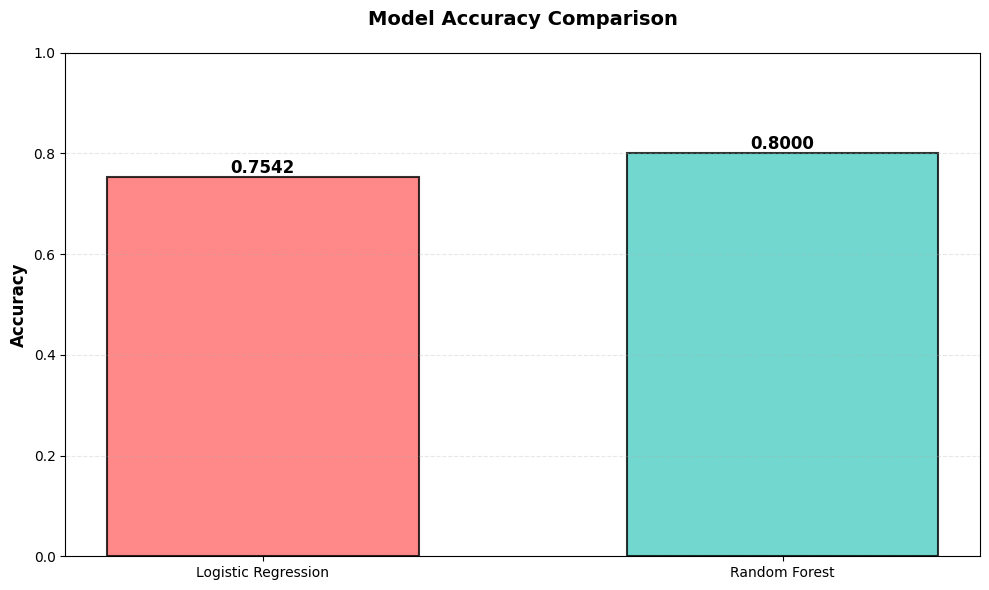

✓ Model comparison chart saved as 'model_comparison_chart.png'


In [25]:
import matplotlib.pyplot as plt

# MODEL COMPARISON VISUALIZATION
fig, ax = plt.subplots(figsize=(10, 6))
models = comparison['Model'].values
accuracies = comparison['Accuracy'].values

bars = ax.bar(models, accuracies, color=['#FF6B6B', '#4ECDC4'], width=0.6, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Model comparison chart saved as 'model_comparison_chart.png'")

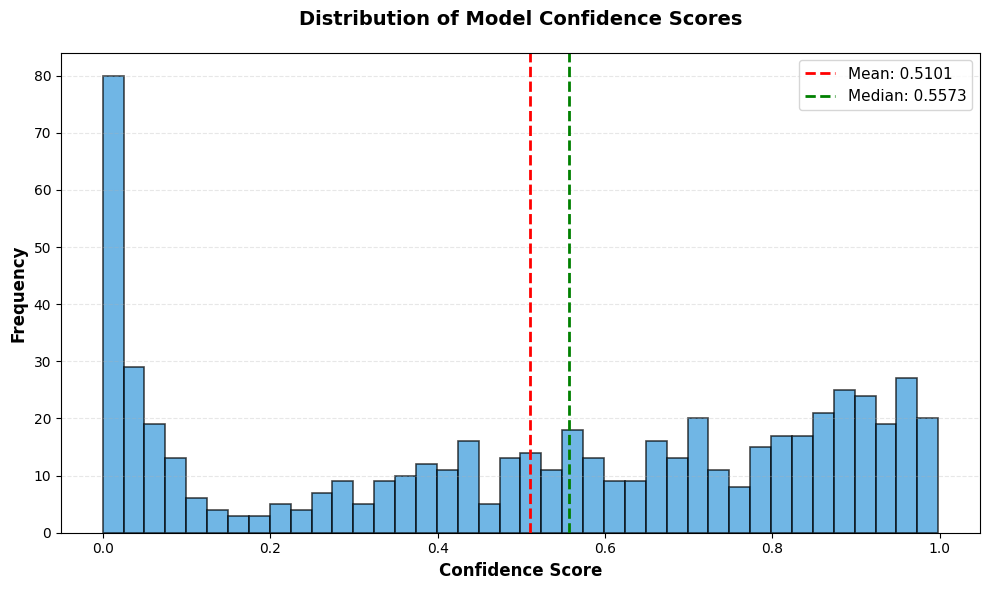

✓ Confidence distribution chart saved as 'confidence_distribution.png'


In [26]:
# CONFIDENCE DISTRIBUTION VISUALIZATION
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(results['Confidence'], bins=40, color='#3498DB', alpha=0.7, edgecolor='black', linewidth=1.2)
ax.axvline(results['Confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results["Confidence"].mean():.4f}')
ax.axvline(results['Confidence'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {results["Confidence"].median():.4f}')

ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Model Confidence Scores', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confidence distribution chart saved as 'confidence_distribution.png'")

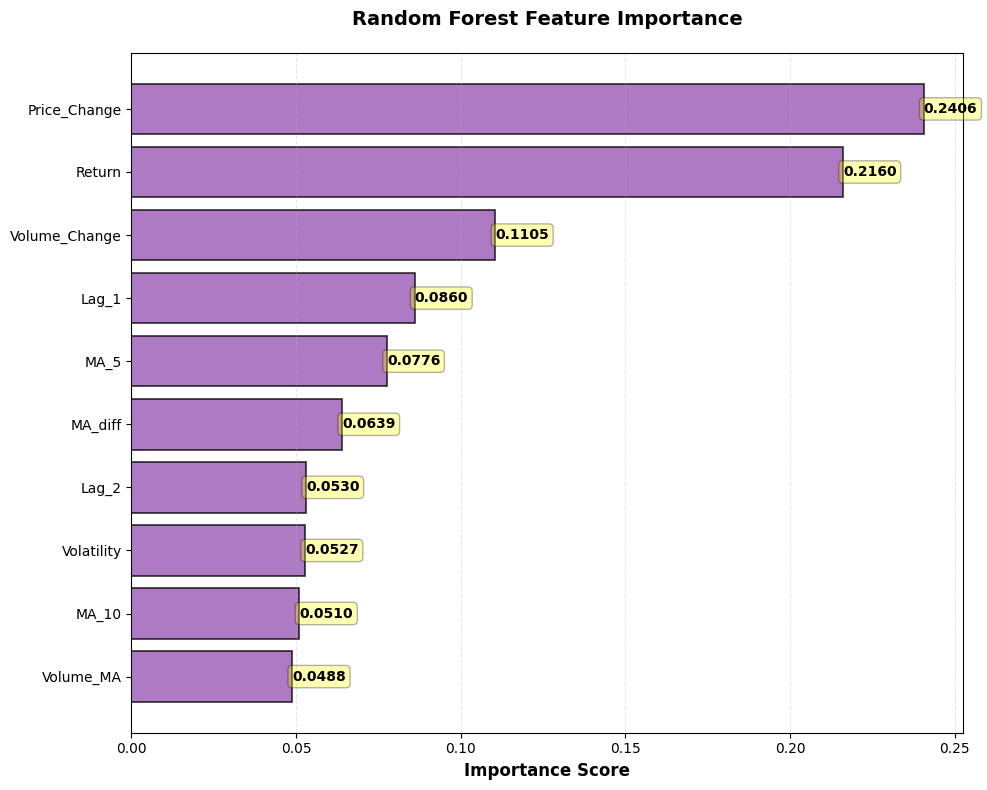

✓ Feature importance chart saved as 'feature_importance.png'

Top 3 Most Important Features:
  Volume_Change: 0.1105
  Return: 0.2160
  Price_Change: 0.2406


In [27]:
# FEATURE IMPORTANCE VISUALIZATION
feature_importance = pipeline.named_steps['classifier'].feature_importances_
feature_names = features

# Create sorted data
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color='#9B59B6', alpha=0.8, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}',
            ha='left', va='center', fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Feature importance chart saved as 'feature_importance.png'")
print("\nTop 3 Most Important Features:")
for idx, row in importance_df.tail(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

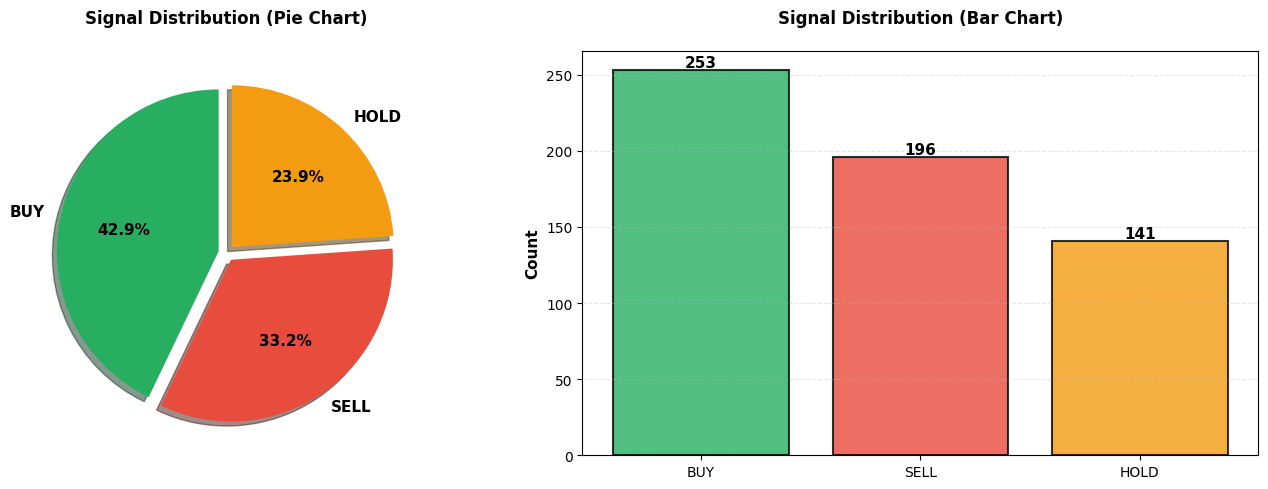

✓ Signal distribution chart saved as 'signal_distribution.png'

Signal Breakdown:
  BUY: 253 (42.9%)
  SELL: 196 (33.2%)
  HOLD: 141 (23.9%)


In [28]:
# SIGNAL DISTRIBUTION VISUALIZATION
signal_counts = results['Signal'].value_counts()
colors = {'BUY': '#27AE60', 'SELL': '#E74C3C', 'HOLD': '#F39C12'}
signal_colors = [colors[signal] for signal in signal_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
wedges, texts, autotexts = ax1.pie(signal_counts.values, labels=signal_counts.index, autopct='%1.1f%%',
                                     colors=signal_colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
                                     explode=(0.05, 0.05, 0.05), shadow=True)
ax1.set_title('Signal Distribution (Pie Chart)', fontsize=12, fontweight='bold', pad=20)

# Bar chart
bars = ax2.bar(signal_counts.index, signal_counts.values, color=signal_colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Signal Distribution (Bar Chart)', fontsize=12, fontweight='bold', pad=20)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('signal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Signal distribution chart saved as 'signal_distribution.png'")
print("\nSignal Breakdown:")
for signal, count in signal_counts.items():
    percentage = (count / len(results)) * 100
    print(f"  {signal}: {count} ({percentage:.1f}%)")